<a href="https://colab.research.google.com/github/Vaibhav5719v/DL_Assignments/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)
print("Class Names  :", iris.target_names)

Feature Shape: (150, 4)
Target Shape : (150,)
Class Names  : ['setosa' 'versicolor' 'virginica']


In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape : (30, 4)


In [7]:
# Standardize the input features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [8]:
# Create Multilayer Perceptron (MLP) Classifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

print(mlp)

MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)


In [9]:
# Train the MLP model

mlp.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# Predict the class labels

y_pred = mlp.predict(X_test)

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.67 %


In [11]:
# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



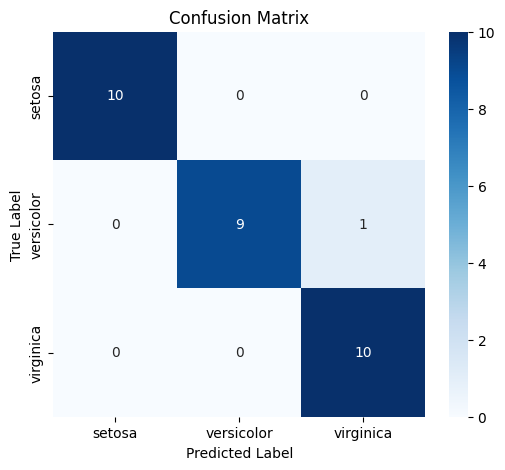

In [12]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

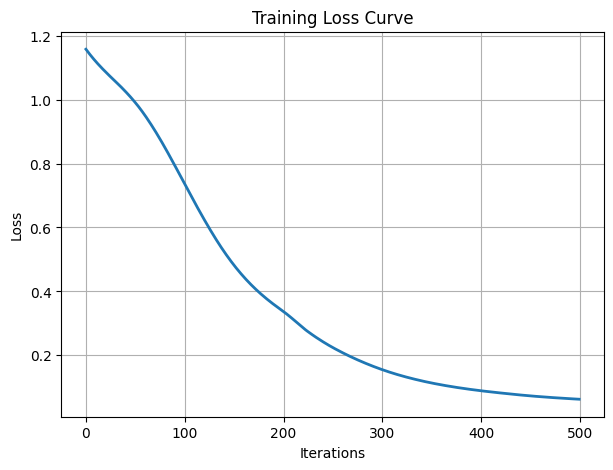

In [13]:
# Plot Training Loss Curve

plt.figure(figsize=(7, 5))

plt.plot(
    mlp.loss_curve_,
    linewidth=2
)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)

plt.show()